In [7]:
print("Seasonal Agriculture Performance Analysis")
print("Project setup successful!")

Seasonal Agriculture Performance Analysis
Project setup successful!


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("Libraries imported successfully!")

Libraries imported successfully!


In [9]:
df = pd.read_csv("../data/seasonal_agriculture_performance_dataset.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 4000
Columns: 28


In [10]:
print("Dataset Information")
print("===================")

print("\nShape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Information

Shape:
(4000, 28)

Column Names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data Types:
Farm_ID                              str
State                                str
District                             str
Crop                                 str
Season                               str
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH       

In [11]:
print("First 5 Records:")
display(df.head())

First 5 Records:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [12]:
print("Missing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest

In [13]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print("Columns with Missing Values:")
print(missing)

Columns with Missing Values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


In [14]:
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df['Soil_Moisture_pct'].median())
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df['Yield_Tonnes_Ha'].median())

print("Missing values handled successfully!")
print("Total missing values:", df.isnull().sum().sum())

Missing values handled successfully!
Total missing values: 0


In [15]:
print("Total Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

Total Missing Values: 0
Duplicate Rows: 0


In [16]:
print("Seasons:")
print(df['Season'].value_counts())

print("\nCrops:")
print(df['Crop'].value_counts())

print("\nStates:")
print(df['State'].value_counts())

print("\nIrrigation Methods:")
print(df['Irrigation_Method'].value_counts())

Seasons:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Crops:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

States:
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

Irrigation Methods:
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


In [17]:
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

print("Average Yield by Season:")
print(season_yield)

Average Yield by Season:
Season
Kharif    5.628612
Rabi      5.039435
Zaid      4.641313
Name: Yield_Tonnes_Ha, dtype: float64


In [18]:
season_performance = df.groupby('Season')[
    ['Production_Tonnes', 'Revenue_INR', 'Total_Cost_INR', 'Profit_INR']
].mean().sort_values('Profit_INR', ascending=False)

print("Average Economic Performance by Season:")
display(season_performance)

Average Economic Performance by Season:


,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR
Season,,,,
Kharif,46.311192,710719.055649,531804.408094,178914.647555
Rabi,41.486712,601526.048556,513836.578365,87689.470191
Zaid,38.886111,519171.904040,543976.728956,-24804.824916


In [19]:
season_environment = df.groupby('Season')[
    ['Rainfall_mm',
     'Avg_Temperature_C',
     'Humidity_pct',
     'Sunlight_Hours_Day',
     'Soil_Moisture_pct']
].mean()

print("Average Environmental Conditions by Season:")
display(season_environment)

Average Environmental Conditions by Season:


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.199663,28.454019,71.812591,6.793367,31.149859
Rabi,437.615366,23.489183,57.893178,7.589797,24.069392
Zaid,304.654714,31.042088,52.012121,8.178788,19.279630


In [20]:
environment_yield_corr = df[
    ['Rainfall_mm',
     'Avg_Temperature_C',
     'Humidity_pct',
     'Sunlight_Hours_Day',
     'Soil_Moisture_pct',
     'Yield_Tonnes_Ha']
].corr()

print("Correlation between Environment and Yield:")
display(environment_yield_corr['Yield_Tonnes_Ha'].sort_values(ascending=False))

Correlation between Environment and Yield:


Yield_Tonnes_Ha       1.000000
Rainfall_mm           0.030951
Humidity_pct          0.012297
Soil_Moisture_pct     0.010999
Avg_Temperature_C     0.009996
Sunlight_Hours_Day   -0.015341
Name: Yield_Tonnes_Ha, dtype: float64

In [21]:
crop_yield = df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

print("Average Yield by Crop:")
print(crop_yield)

Average Yield by Crop:
Crop
Sugarcane    46.642361
Maize         2.710036
Rice          2.431304
Wheat         2.108013
Chilli        1.542767
Groundnut     1.322901
Cotton        1.229783
Pulses        0.921512
Name: Yield_Tonnes_Ha, dtype: float64


In [22]:
crop_season_yield = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

print("Average Yield by Crop and Season:")
display(crop_season_yield)

Average Yield by Crop and Season:


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.731459,1.465031,1.195312
Cotton,1.374512,1.198358,0.960217
Groundnut,1.484974,1.233164,1.037778
Maize,2.966410,2.603648,2.290952
Pulses,1.036063,0.875962,0.669677
Rice,2.698376,2.322847,1.900490
Sugarcane,53.459120,43.286124,38.423922
Wheat,2.253664,2.057468,1.748588


In [23]:
crop_season_count = pd.crosstab(
    df['Crop'],
    df['Season']
)

print("Number of Records by Crop and Season:")
display(crop_season_count)

Number of Records by Crop and Season:


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,185,163,64
Cotton,215,201,92
Groundnut,193,177,54
Maize,234,233,84
Pulses,221,213,62
Rice,314,274,102
Sugarcane,125,129,51
Wheat,292,237,85


In [24]:
season_resources = df.groupby('Season')[
    [
        'Fertilizer_kg_ha',
        'Pesticide_Litre_ha',
        'Water_Used_m3',
        'Water_Efficiency_t_per_1000m3'
    ]
].mean().sort_values('Water_Efficiency_t_per_1000m3', ascending=False)

print("Average Resource Usage by Season:")
display(season_resources)

Average Resource Usage by Season:


,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,
Kharif,187.077965,5.079747,6102.201237,5.891834
Rabi,185.407068,5.024690,5846.987093,5.186122
Zaid,184.638047,5.171212,6419.893939,4.413239


In [25]:
df['Profit_Margin_pct'] = (
    df['Profit_INR'] / df['Revenue_INR']
) * 100

season_profit_margin = df.groupby('Season')['Profit_Margin_pct'].mean().sort_values(
    ascending=False
)

print("Average Profit Margin by Season:")
print(season_profit_margin)

Average Profit Margin by Season:
Season
Kharif   -38.644541
Rabi     -44.267645
Zaid     -69.354573
Name: Profit_Margin_pct, dtype: float64


In [26]:
season_financials = df.groupby('Season')[
    ['Revenue_INR', 'Total_Cost_INR', 'Profit_INR']
].mean()

print("Average Financial Performance by Season:")
display(season_financials)

Average Financial Performance by Season:


,Revenue_INR,Total_Cost_INR,Profit_INR
Season,,,
Kharif,710719.055649,531804.408094,178914.647555
Rabi,601526.048556,513836.578365,87689.470191
Zaid,519171.904040,543976.728956,-24804.824916


In [27]:
season_profit_margin = (
    (season_financials['Profit_INR'] / season_financials['Revenue_INR']) * 100
).sort_values(ascending=False)

print("Profit Margin by Season:")
print(season_profit_margin)

Profit Margin by Season:
Season
Kharif    25.173751
Rabi      14.577834
Zaid      -4.777767
dtype: float64


In [28]:
state_performance = df.groupby('State')[
    ['Yield_Tonnes_Ha', 'Revenue_INR', 'Profit_INR']
].mean().sort_values('Profit_INR', ascending=False)

print("Average Performance by State:")
display(state_performance)

Average Performance by State:


,Yield_Tonnes_Ha,Revenue_INR,Profit_INR
State,,,
Punjab,6.121116,686225.702479,136025.636364
Maharashtra,5.017480,650032.669922,135428.855469
Karnataka,5.685481,653426.182004,119422.335378
Tamil Nadu,4.875175,629093.416495,117744.748454
Gujarat,5.659016,654692.860656,117568.235656
Telangana,5.044477,628784.532946,108829.616279
Madhya Pradesh,4.989940,597558.358149,86840.756539
Andhra Pradesh,4.628771,606663.659735,73453.527410


In [29]:
state_season_profit = df.pivot_table(
    values='Profit_INR',
    index='State',
    columns='Season',
    aggfunc='mean'
)

print("Average Profit by State and Season:")
display(state_season_profit)

Average Profit by State and Season:


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169315.520833,26315.710784,-84084.870588
Gujarat,217051.330317,82846.195000,-106929.611940
Karnataka,201226.205742,70952.611650,23310.905405
Madhya Pradesh,134242.398230,61576.264423,209.698413
Maharashtra,168801.049550,159581.504587,-40597.597222
Punjab,133779.099548,169294.521505,62109.688312
Tamil Nadu,211303.956311,70456.860577,-15175.197183
Telangana,199668.380342,62824.604061,-34620.776471


## 5. Data Visualization

The following visualizations present the main seasonal patterns identified in the analysis. The existing calculations and dataset are kept unchanged.


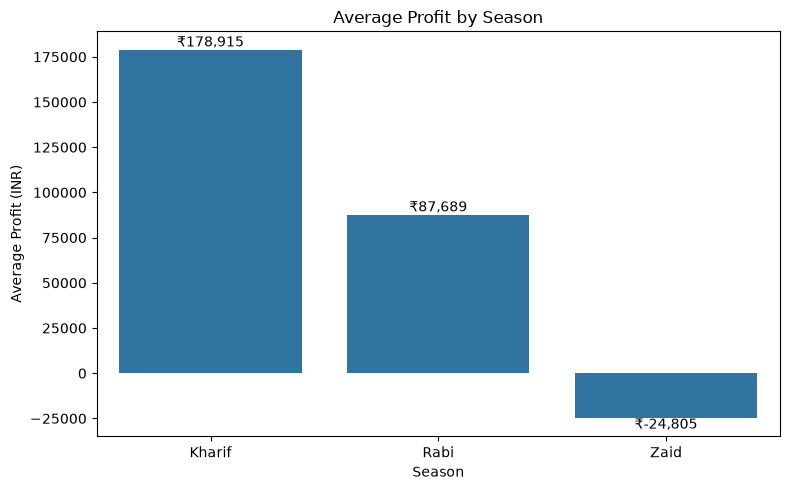

In [30]:
# 1. Average Profit by Season
profit_by_season = df.groupby('Season')['Profit_INR'].mean().reindex(['Kharif', 'Rabi', 'Zaid'])

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=profit_by_season.index, y=profit_by_season.values)
plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=0)
for i, value in enumerate(profit_by_season.values):
    ax.text(i, value, f'₹{value:,.0f}', ha='center', va='bottom' if value >= 0 else 'top')
plt.tight_layout()
plt.show()


<Figure size 1100x600 with 0 Axes>

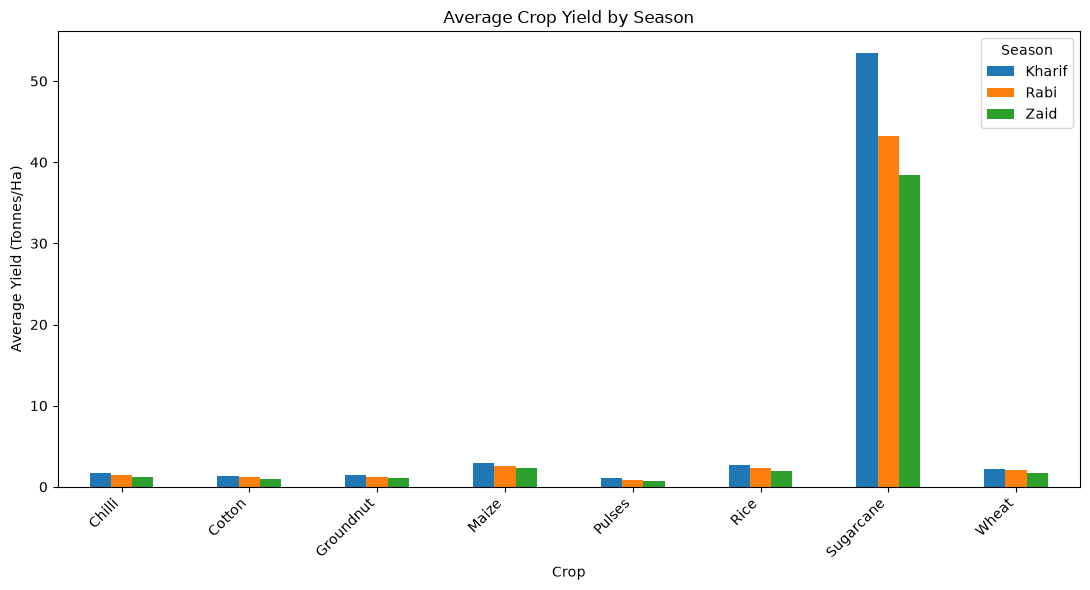

In [31]:
# 2. Average Crop Yield by Season
yield_plot = crop_season_yield.reindex(columns=['Kharif', 'Rabi', 'Zaid'])

plt.figure(figsize=(11, 6))
yield_plot.plot(kind='bar', figsize=(11, 6))
plt.title('Average Crop Yield by Season')
plt.xlabel('Crop')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Season')
plt.tight_layout()
plt.show()


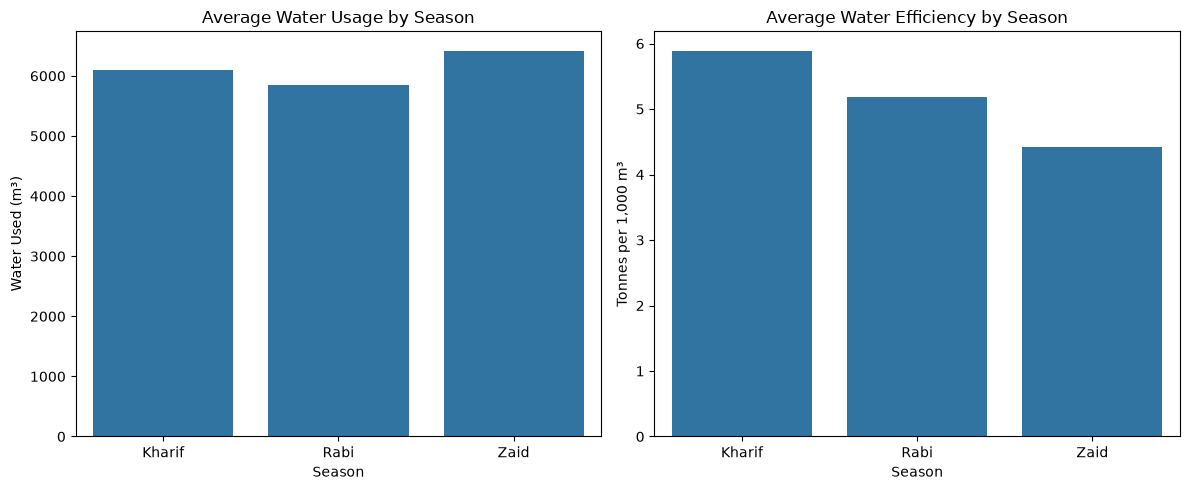

In [32]:
# 3. Water Usage and Water Efficiency by Season
resource_plot = season_resources.reindex(['Kharif', 'Rabi', 'Zaid'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=resource_plot.index, y=resource_plot['Water_Used_m3'], ax=axes[0])
axes[0].set_title('Average Water Usage by Season')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Water Used (m³)')

sns.barplot(x=resource_plot.index, y=resource_plot['Water_Efficiency_t_per_1000m3'], ax=axes[1])
axes[1].set_title('Average Water Efficiency by Season')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Tonnes per 1,000 m³')

plt.tight_layout()
plt.show()


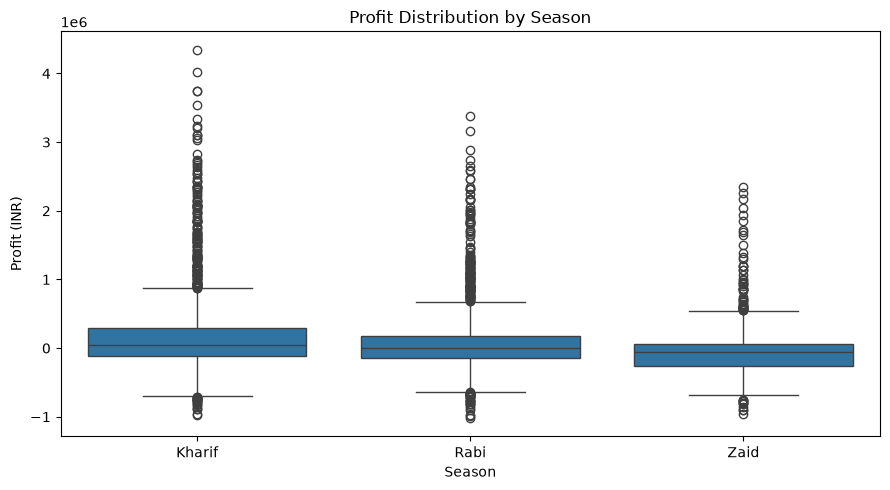

In [33]:
# 4. Profit Distribution by Season
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Season', y='Profit_INR', order=['Kharif', 'Rabi', 'Zaid'])
plt.title('Profit Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Profit (INR)')
plt.tight_layout()
plt.show()


In [34]:
season_groups = [
    df[df['Season'] == 'Kharif']['Yield_Tonnes_Ha'],
    df[df['Season'] == 'Rabi']['Yield_Tonnes_Ha'],
    df[df['Season'] == 'Zaid']['Yield_Tonnes_Ha']
]

f_stat, p_value = stats.f_oneway(*season_groups)

print("One-Way ANOVA for Yield by Season")
print("F-statistic:", f_stat)
print("P-value:", p_value)

One-Way ANOVA for Yield by Season
F-statistic: 1.5438804542488314
P-value: 0.21367813841845007


In [35]:
season_profit_groups = [
    df[df['Season'] == 'Kharif']['Profit_INR'],
    df[df['Season'] == 'Rabi']['Profit_INR'],
    df[df['Season'] == 'Zaid']['Profit_INR']
]

f_stat, p_value = stats.f_oneway(*season_profit_groups)

print("One-Way ANOVA for Profit by Season")
print("F-statistic:", f_stat)
print("P-value:", p_value)

One-Way ANOVA for Profit by Season
F-statistic: 34.29175033935196
P-value: 1.7124156677397172e-15


In [36]:
from scipy.stats import ttest_ind

kharif = df[df['Season'] == 'Kharif']['Profit_INR']
rabi = df[df['Season'] == 'Rabi']['Profit_INR']
zaid = df[df['Season'] == 'Zaid']['Profit_INR']

print("Kharif vs Rabi:", ttest_ind(kharif, rabi, equal_var=False))
print("Kharif vs Zaid:", ttest_ind(kharif, zaid, equal_var=False))
print("Rabi vs Zaid:", ttest_ind(rabi, zaid, equal_var=False))

Kharif vs Rabi: TtestResult(statistic=np.float64(4.823156521372228), pvalue=np.float64(1.4760791145702675e-06), df=np.float64(3346.7563270787236))
Kharif vs Zaid: TtestResult(statistic=np.float64(8.842525137620628), pvalue=np.float64(2.7109987650973882e-18), df=np.float64(1421.8968632090885))
Rabi vs Zaid: TtestResult(statistic=np.float64(5.199697292314236), pvalue=np.float64(2.3532222670381492e-07), df=np.float64(1173.7109471768756))


In [37]:
Q1 = df['Profit_INR'].quantile(0.25)
Q3 = df['Profit_INR'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

profit_outliers = df[
    (df['Profit_INR'] < lower_bound) |
    (df['Profit_INR'] > upper_bound)
]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Profit Outliers:", len(profit_outliers))

Lower Bound: -696111.0
Upper Bound: 763567.0
Number of Profit Outliers: 404


In [38]:
profit_outliers_by_season = profit_outliers['Season'].value_counts()

print("Profit Outliers by Season:")
print(profit_outliers_by_season)

print("\nPercentage of Outliers by Season:")
print((profit_outliers_by_season / len(profit_outliers) * 100).round(2))

Profit Outliers by Season:
Season
Kharif    211
Rabi      150
Zaid       43
Name: count, dtype: int64

Percentage of Outliers by Season:
Season
Kharif    52.23
Rabi      37.13
Zaid      10.64
Name: count, dtype: float64


In [39]:
season_outlier_summary = pd.DataFrame({
    'Total_Records': df['Season'].value_counts(),
    'Outliers': profit_outliers['Season'].value_counts()
})

season_outlier_summary['Outlier_Percentage'] = (
    season_outlier_summary['Outliers'] /
    season_outlier_summary['Total_Records'] * 100
)

season_outlier_summary = season_outlier_summary.sort_values(
    'Outlier_Percentage',
    ascending=False
)

print("Season-wise Profit Outlier Analysis:")
display(season_outlier_summary)

Season-wise Profit Outlier Analysis:


,Total_Records,Outliers,Outlier_Percentage
Season,,,
Kharif,1779,211,11.860596
Rabi,1627,150,9.219422
Zaid,594,43,7.239057


In [40]:
water_profit_corr = df[['Water_Used_m3', 'Profit_INR']].corr()

print("Correlation between Water Usage and Profit:")
display(water_profit_corr)

Correlation between Water Usage and Profit:


,Water_Used_m3,Profit_INR
Water_Used_m3,1.000000,0.190278
Profit_INR,0.190278,1.000000


In [41]:
print("KEY FINDINGS FROM SEASONAL AGRICULTURE ANALYSIS")
print("=" * 55)

print("\n1. Seasonal Yield:")
print("Kharif recorded the highest average yield, followed by Rabi and Zaid.")

print("\n2. Seasonal Profitability:")
print("Kharif had the highest average profit, Rabi had lower positive profit,")
print("while Zaid recorded a negative average profit.")

print("\n3. Environmental Conditions:")
print("Kharif had the highest average rainfall and soil moisture,")
print("while Zaid had the highest average temperature and sunlight.")

print("\n4. Crop-wise Seasonal Pattern:")
print("All analyzed crops showed the pattern: Kharif yield > Rabi yield > Zaid yield.")

print("\n5. Resource Efficiency:")
print("Kharif showed the highest average water-use efficiency,")
print("while Zaid showed the lowest.")

print("\n6. State-wise Performance:")
print("Punjab recorded the highest average yield and average profit among the states.")

print("\n7. Statistical Findings:")
print("Seasonal differences in yield were not statistically significant at the 5% level.")
print("Seasonal differences in profit were statistically significant.")

print("\n8. Profit Outliers:")
print("Kharif had the highest season-wise proportion of profit outliers.")

print("\n9. Water Usage and Profit:")
print("Water usage showed a weak positive correlation with profit (r ≈ 0.19).")

KEY FINDINGS FROM SEASONAL AGRICULTURE ANALYSIS

1. Seasonal Yield:
Kharif recorded the highest average yield, followed by Rabi and Zaid.

2. Seasonal Profitability:
Kharif had the highest average profit, Rabi had lower positive profit,
while Zaid recorded a negative average profit.

3. Environmental Conditions:
Kharif had the highest average rainfall and soil moisture,
while Zaid had the highest average temperature and sunlight.

4. Crop-wise Seasonal Pattern:
All analyzed crops showed the pattern: Kharif yield > Rabi yield > Zaid yield.

5. Resource Efficiency:
Kharif showed the highest average water-use efficiency,
while Zaid showed the lowest.

6. State-wise Performance:
Punjab recorded the highest average yield and average profit among the states.

7. Statistical Findings:
Seasonal differences in yield were not statistically significant at the 5% level.
Seasonal differences in profit were statistically significant.

8. Profit Outliers:
Kharif had the highest season-wise proportion

In [42]:
print("RECOMMENDATIONS")
print("=" * 40)

print("\n1. Seasonal Planning:")
print("Farmers should consider seasonal differences when planning crop production and resource allocation.")

print("\n2. Improve Zaid Season Performance:")
print("Zaid showed lower average yield, negative average profit, and lower water-use efficiency.")
print("Resource use and crop selection during Zaid should therefore be carefully optimized.")

print("\n3. Improve Water Management:")
print("Since Zaid used the highest average water but had the lowest water-use efficiency,")
print("better irrigation scheduling and water management may improve resource efficiency.")

print("\n4. Focus on Profitable Seasons:")
print("Kharif showed the highest average profit and profit margin.")
print("Practices associated with stronger Kharif performance can be studied for other seasons.")

print("\n5. Crop-specific Planning:")
print("Since every crop showed higher average yield in Kharif than Rabi and Zaid,")
print("crop and season combinations should be considered when planning cultivation.")

print("\n6. Regional Planning:")
print("State-level and state-season differences in profit suggest that regional conditions")
print("should be considered when making agricultural planning decisions.")

print("\n7. Monitor Unusual Profit Values:")
print("Profit outliers should be investigated to understand unusual production, cost,")
print("revenue, or market conditions rather than automatically treating them as errors.")

print("\n8. Data-driven Decision Making:")
print("Future agricultural decisions should combine seasonal, crop, environmental,")
print("resource, and economic indicators instead of relying on a single factor.")

RECOMMENDATIONS

1. Seasonal Planning:
Farmers should consider seasonal differences when planning crop production and resource allocation.

2. Improve Zaid Season Performance:
Zaid showed lower average yield, negative average profit, and lower water-use efficiency.
Resource use and crop selection during Zaid should therefore be carefully optimized.

3. Improve Water Management:
Since Zaid used the highest average water but had the lowest water-use efficiency,
better irrigation scheduling and water management may improve resource efficiency.

4. Focus on Profitable Seasons:
Kharif showed the highest average profit and profit margin.
Practices associated with stronger Kharif performance can be studied for other seasons.

5. Crop-specific Planning:
Since every crop showed higher average yield in Kharif than Rabi and Zaid,
crop and season combinations should be considered when planning cultivation.

6. Regional Planning:
State-level and state-season differences in profit suggest that regio

In [43]:
print("CONCLUSION")
print("=" * 40)

print("\nThe analysis shows clear seasonal patterns in agricultural performance.")
print("Kharif recorded the highest average yield, profit, profit margin, and water-use efficiency,")
print("while Zaid generally showed weaker economic and resource-efficiency performance.")

print("\nAlthough environmental conditions varied considerably across seasons,")
print("the overall record-level correlations between individual environmental factors and yield")
print("were weak. Therefore, the observed seasonal differences should not be interpreted as")
print("direct causal effects of any single environmental factor.")

print("\nCrop-wise analysis showed that all analyzed crops had higher average yields in Kharif")
print("than in Rabi and Zaid, indicating a consistent seasonal pattern across crops.")

print("\nProfit analysis showed statistically significant differences between seasons.")
print("All three pairwise seasonal profit comparisons were also statistically significant.")
print("In contrast, the difference in seasonal mean yield was not statistically significant")
print("at the 5% significance level.")

print("\nResource analysis highlighted the importance of water management.")
print("Zaid had the highest average water usage but the lowest water-use efficiency.")
print("Water usage and profit showed only a weak positive correlation (r ≈ 0.19).")

print("\nOverall, the findings demonstrate that seasonal, crop, regional, resource,")
print("and economic factors should be considered together when evaluating agricultural performance.")

CONCLUSION

The analysis shows clear seasonal patterns in agricultural performance.
Kharif recorded the highest average yield, profit, profit margin, and water-use efficiency,
while Zaid generally showed weaker economic and resource-efficiency performance.

Although environmental conditions varied considerably across seasons,
the overall record-level correlations between individual environmental factors and yield
were weak. Therefore, the observed seasonal differences should not be interpreted as
direct causal effects of any single environmental factor.

Crop-wise analysis showed that all analyzed crops had higher average yields in Kharif
than in Rabi and Zaid, indicating a consistent seasonal pattern across crops.

Profit analysis showed statistically significant differences between seasons.
All three pairwise seasonal profit comparisons were also statistically significant.
In contrast, the difference in seasonal mean yield was not statistically significant
at the 5% significance leve

# Seasonal Agriculture Performance Analysis

## Major Project — Seasonal Agricultural Data Analysis

This project analyzes seasonal variations in agricultural performance using
production, environmental, resource-use, and economic indicators.

### Objectives

- Understand and explore the agricultural dataset
- Clean and prepare the data for analysis
- Compare agricultural performance across seasons
- Identify seasonal patterns and trends
- Analyze relationships between environmental and agricultural outcomes
- Compare crop-wise and state-wise performance
- Evaluate resource usage and water efficiency
- Perform statistical analysis to identify significant differences
- Identify unusual profit patterns and outliers
- Develop data-driven findings and recommendations

## 1. Dataset Overview

The dataset contains 4,000 records and 28 variables related to agricultural
activities across different seasons, crops, states, environmental conditions,
resource usage, production, and financial performance.

The main categories of information include:

- Farm and geographical information
- Crop and seasonal information
- Environmental conditions
- Soil and nutrient characteristics
- Irrigation and resource usage
- Crop yield and production
- Market price, cost, revenue, and profit
- Water-use efficiency
- Disease and pest risk

The analysis focuses on identifying seasonal patterns, differences,
relationships, unusual observations, and factors associated with agricultural
performance.

## 2. Libraries and Project Setup

The analysis is performed using Python and commonly used data analysis,
statistical analysis, and visualization libraries.

The following libraries are used:

- **Pandas** — data loading, cleaning, grouping, and analysis
- **NumPy** — numerical operations
- **Matplotlib** — data visualization
- **Seaborn** — statistical visualization
- **SciPy** — statistical testing and analysis

The dataset is loaded from a CSV file and analyzed using a Pandas DataFrame.

## 3. Data Loading and Initial Inspection

The agricultural dataset is loaded from a CSV file into a Pandas DataFrame.

After loading the dataset, its basic structure is examined by checking:

- Number of rows and columns
- Column names
- First few records
- Data completeness
- Duplicate records
- Categorical distributions

## 4. Data Cleaning and Preprocessing

Before performing the analysis, the dataset is checked for missing values and
duplicate records.

Missing numerical values are handled using the median of the corresponding
column. This approach reduces the effect of extreme values while preserving
the overall distribution of the data.

The dataset is then rechecked to confirm that:

- Missing values have been handled
- Duplicate records are absent
- The dataset is ready for further analysis

## 5. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the major patterns
and variations present in the agricultural dataset.

The analysis examines:

- Distribution of agricultural records across seasons
- Crop-wise distribution
- Average yield across seasons
- Economic performance across seasons
- Environmental conditions across seasons
- Crop-wise and season-wise yield
- Resource usage and water-use efficiency
- State-wise agricultural performance
- State and season-wise profit patterns

These comparisons help identify important differences and patterns before
performing statistical analysis.

## 6. Statistical Analysis

Statistical tests are performed to determine whether the observed differences
between agricultural seasons are statistically significant.

The following tests are used:

- **One-Way ANOVA for Yield** — to examine whether mean yield differs
  significantly across Kharif, Rabi, and Zaid seasons.
- **One-Way ANOVA for Profit** — to examine whether mean profit differs
  significantly across seasons.
- **Welch's Independent t-tests** — to compare profit between each pair of
  seasons.

A significance level of 5% (α = 0.05) is used for interpreting the results.

## 7. Outlier and Relationship Analysis

Further analysis is performed to identify unusual profit observations and
examine relationships between important agricultural variables.

The analysis includes:

- Identification of profit outliers using the Interquartile Range (IQR) method
- Comparison of profit outlier proportions across seasons
- Correlation between water usage and profit
- Interpretation of the strength and direction of observed relationships

Outliers are treated as unusual observations rather than automatically being
considered errors.

## 8. Key Findings

The analysis produced several important findings regarding seasonal
agricultural performance.

The major findings are summarized below:

- Kharif recorded the highest average yield.
- Kharif showed the highest average profit and profit margin.
- Zaid recorded negative average profit and the lowest water-use efficiency.
- All analyzed crops showed higher average yield in Kharif than in Rabi and Zaid.
- Punjab recorded the highest average yield and average profit among the analyzed states.
- Seasonal differences in mean profit were statistically significant.
- Seasonal differences in mean yield were not statistically significant at the 5% level.
- Kharif had the highest proportion of profit outliers.
- Water usage and profit showed a weak positive correlation.

## 9. Recommendations

Based on the findings of the analysis, the following recommendations are
proposed:

- Consider seasonal differences when planning crop production and resource allocation.
- Improve crop selection and resource management during the Zaid season.
- Optimize irrigation scheduling and water management to improve water-use efficiency.
- Study practices associated with stronger Kharif performance for possible application in other seasons.
- Consider crop-season combinations when planning cultivation.
- Incorporate regional differences into agricultural planning decisions.
- Investigate unusual profit observations to understand the factors behind extreme outcomes.
- Use seasonal, crop, environmental, resource, and economic indicators together for data-driven decisions.

## 10. Conclusion

The analysis provides an overall understanding of seasonal agricultural
performance across different crops, states, environmental conditions, resource
usage, and economic indicators.

The results show that Kharif generally performed better in terms of yield,
profitability, and water-use efficiency, while Zaid showed weaker economic and
resource-efficiency outcomes.

Statistical analysis found significant seasonal differences in profit, whereas
the observed differences in mean yield were not statistically significant at
the 5% significance level.

Overall, the study demonstrates the importance of considering seasonal, crop,
regional, environmental, resource, and economic factors together when
evaluating agricultural performance and making data-driven decisions.